## 0. Environment Setup

In [1]:
import warnings
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf

warnings.filterwarnings("ignore")
plt.style.use("dark_background")

COLORS = {
    "primary": "#4FC3F7",
    "success": "#66BB6A",
    "danger": "#EF5350",
    "warning": "#FFA726",
    "accent": "#AB47BC",
    "neutral": "#B0BEC5",
}

# ── V3 Architecture Constants (backend/config/constants.py) ─────────────────
EMBEDDING_DIM_TEMPORAL = 128  # TFT output dimension
SEQ_LEN = 60  # 60-bar lookback window (1h bars)
STATIC_DIM = 8  # Static covariate encoded dimension
HIDDEN_DIM = 64  # TFT hidden state dimension
N_HEADS = 4  # Multi-head attention heads
N_ENCODER_LAYERS = 2  # Stacked TFT layers
DROPOUT_RATE = 0.1  # Monte Carlo Dropout (shared with uncertainty)
BATCH_SIZE = 128
LR = 3e-4
N_EPOCHS = 50

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import RobustScaler

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch {torch.__version__} | Device: {DEVICE}")
except ImportError:
    print("PyTorch not installed. Run: pip install torch")
    raise

PyTorch 2.10.0+cu128 | Device: cuda


## 1. Data Preparation

In [2]:
# Load feature dataset from notebook 02 (or rebuild if missing)
FEATURE_FILE = Path("02/02_features_spy.parquet")

if FEATURE_FILE.exists():
    df = pd.read_parquet(FEATURE_FILE)
    print(f"Loaded features from {FEATURE_FILE} → shape: {df.shape}")
else:
    print("Feature file not found — downloading raw data...")
    END = datetime.today()
    START = END - timedelta(days=365 * 3)
    raw = yf.download(
        "SPY",
        start=START,
        end=END,
        interval="1h",
        progress=False,
        auto_adjust=True,
    )
    df = raw.copy()

    # ── Flatten MultiIndex columns (yfinance ≥0.2 returns MultiIndex) ───────
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
        df.columns.name = None

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
    df.dropna(inplace=True)
    print(f"Downloaded SPY 1h → shape: {df.shape}")

# ── Feature groups for TFT input ────────────────────────────────────────────
DYNAMIC_FEATURES = [
    "log_return",
    "high_low_pct" if "high_low_pct" in df.columns else "log_return",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Hist",
    "BB_PctB",
    "BB_Width",
    "ATR_14",
]
# Filter to columns that exist, then deduplicate while preserving order
seen = set()
DYNAMIC_FEATURES = [
    f
    for f in DYNAMIC_FEATURES
    if f in df.columns and not (f in seen or seen.add(f))
]

TIME_FEATURES = [
    f
    for f in df.columns
    if any(
        k in f
        for k in [
            "hour_sin",
            "hour_cos",
            "dow_sin",
            "dow_cos",
            "month_sin",
            "month_cos",
            "is_open",
        ]
    )
]

ALL_FEATURES = DYNAMIC_FEATURES + TIME_FEATURES
TARGET_COL = "log_return"

print(f"Dynamic features  : {len(DYNAMIC_FEATURES)} → {DYNAMIC_FEATURES}")
print(f"Time features     : {len(TIME_FEATURES)} → {TIME_FEATURES}")
print(f"Total input dim   : {len(ALL_FEATURES)}")
print(f"DataFrame shape   : {df.shape}")
print(
    f"NaN counts in ALL_FEATURES:\n{df[ALL_FEATURES].isna().sum().to_string()}"
)

Loaded features from 02/02_features_spy.parquet → shape: (3464, 27)
Dynamic features  : 8 → ['log_return', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_PctB', 'BB_Width', 'ATR_14']
Time features     : 7 → ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_open']
Total input dim   : 15
DataFrame shape   : (3464, 27)
NaN counts in ALL_FEATURES:
log_return     0
RSI_14         0
MACD           0
MACD_Signal    0
MACD_Hist      0
BB_PctB        0
BB_Width       0
ATR_14         0
hour_sin       0
hour_cos       0
dow_sin        0
dow_cos        0
month_sin      0
month_cos      0
is_open        0


## 2. Variable Selection Network (VSN) Component

In [3]:
class GatedResidualNetwork(nn.Module):
    """
    Gated Residual Network (GRN) — fundamental building block of the TFT.
    Applies a gated skip connection that allows the model to select which
    transformations are relevant for the current input.
    Reference: Lim et al. 2021, "Temporal Fusion Transformers for
    Interpretable Multi-horizon Time Series Forecasting."
    """

    def __init__(
        self,
        input_dim: int,
        hidden_dim: int,
        output_dim: int,
        dropout: float = 0.1,
        context_dim: int | None = None,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.output_dim = output_dim

        # Primary dense path
        self.fc1 = nn.Linear(input_dim + (context_dim or 0), hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, output_dim)
        self.elu = nn.ELU()

        # Gating layer (controls how much of the residual to pass through)
        self.gate = nn.Linear(output_dim, output_dim)
        self.sig = nn.Sigmoid()
        self.drop = nn.Dropout(dropout)
        self.ln = nn.LayerNorm(output_dim)

        # Skip projection when dimensions differ
        self.skip = (
            nn.Linear(input_dim, output_dim)
            if input_dim != output_dim
            else nn.Identity()
        )

    def forward(
        self, x: torch.Tensor, context: torch.Tensor | None = None
    ) -> torch.Tensor:
        h = x if context is None else torch.cat([x, context], dim=-1)
        h = self.elu(self.fc1(h))
        h = self.drop(self.fc2(h))

        gate = self.sig(self.gate(h))
        skip = self.skip(x)
        return self.ln(gate * h + (1 - gate) * skip)


class VariableSelectionNetwork(nn.Module):
    """
    VSN — learns to gate individual input features, dynamically selecting
    which variables matter for each time step.
    "Automatically learns to ignore volume data during low-liquidity
    after-hours trading." (§3-A)
    """

    def __init__(
        self,
        n_features: int,
        hidden_dim: int,
        dropout: float = 0.1,
        context_dim: int = 0,
    ):
        super().__init__()
        self.n_features = n_features
        self.hidden_dim = hidden_dim

        # Per-feature GRN
        self.grns = nn.ModuleList(
            [
                GatedResidualNetwork(
                    1, hidden_dim, hidden_dim, dropout, context_dim
                )
                for _ in range(n_features)
            ]
        )

        # Softmax selector over all features
        self.softmax_grn = GatedResidualNetwork(
            n_features, hidden_dim, n_features, dropout, context_dim
        )
        self.softmax = nn.Softmax(dim=-1)

    def forward(
        self, x: torch.Tensor, context: torch.Tensor | None = None
    ) -> tuple:
        """
        Args:
            x: (batch, n_features)
            context: (batch, context_dim) optional static covariates
        Returns:
            selected: (batch, hidden_dim) — weighted feature vector
            weights: (batch, n_features) — attention weights (interpretable!)
        """
        # Process each feature independently
        processed = [
            self.grns[i](x[:, i : i + 1], context)
            for i in range(self.n_features)
        ]  # List of (batch, hidden_dim)

        # Compute selection weights
        flat_weights = self.softmax(
            self.softmax_grn(x, context)
        )  # (batch, n_features)

        # Weighted sum of processed features
        stacked = torch.stack(
            processed, dim=-1
        )  # (batch, hidden_dim, n_features)
        selected = (stacked * flat_weights.unsqueeze(1)).sum(
            dim=-1
        )  # (batch, hidden_dim)

        return selected, flat_weights


print("GatedResidualNetwork ✅")
print("VariableSelectionNetwork ✅")

GatedResidualNetwork ✅
VariableSelectionNetwork ✅


## 3. Full TFT Temporal Encoder

In [4]:
class TemporalFusionTransformerEncoder(nn.Module):
    """
    Simplified TFT Encoder that produces the 128-dimensional temporal
    embedding for the Chimera Super-State.

    Architecture flow:
      Input (batch, seq_len, n_features)
        → VSN per time step (feature gating)
        → LSTM (sequential processing with static covariate conditioning)
        → Multi-head Self-Attention (long-range dependency capture)
        → GRN (post-attention refinement)
        → Linear projection → 128d embedding

    Output: (batch, EMBEDDING_DIM_TEMPORAL=128)

    This is the component that maps to:
      backend/perception/temporal/encoder.py  →  class TemporalEncoder
    """

    def __init__(
        self,
        n_input_features: int,
        n_static_features: int,
        hidden_dim: int = HIDDEN_DIM,
        n_heads: int = N_HEADS,
        n_lstm_layers: int = N_ENCODER_LAYERS,
        output_dim: int = EMBEDDING_DIM_TEMPORAL,
        dropout: float = DROPOUT_RATE,
    ):
        super().__init__()

        self.n_features = n_input_features
        self.hidden_dim = hidden_dim

        # Static covariate encoder (asset metadata conditioning)
        self.static_encoder = nn.Sequential(
            nn.Linear(n_static_features, hidden_dim),
            nn.ELU(),
            nn.Linear(hidden_dim, hidden_dim),
        )

        # Variable Selection Network for dynamic features
        self.vsn = VariableSelectionNetwork(
            n_features=n_input_features,
            hidden_dim=hidden_dim,
            dropout=dropout,
            context_dim=hidden_dim,  # conditioned on static covariates
        )

        # LSTM backbone — sequential temporal processing
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=n_lstm_layers,
            batch_first=True,
            dropout=dropout if n_lstm_layers > 1 else 0.0,
        )

        # Multi-head Self-Attention — captures long-range dependencies
        self.self_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        # Post-attention GRN
        self.post_attn_grn = GatedResidualNetwork(
            input_dim=hidden_dim,
            hidden_dim=hidden_dim,
            output_dim=hidden_dim,
            dropout=dropout,
        )

        # Layer normalisation
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.ln2 = nn.LayerNorm(hidden_dim)
        self.drop = nn.Dropout(dropout)

        # Output projection → EMBEDDING_DIM_TEMPORAL (128d)
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, output_dim),
            nn.Tanh(),  # Bounded embedding — stable for fusion concatenation
        )

    def forward(self, x: torch.Tensor, static: torch.Tensor) -> tuple:
        """
        Args:
            x      : (batch, seq_len, n_features) — dynamic input sequence
            static : (batch, n_static_features)   — static asset covariates
        Returns:
            embedding      : (batch, 128) — the temporal price embedding
            vsn_weights    : (batch, seq_len, n_features) — interpretable attention
            attn_weights   : (batch, seq_len, seq_len)   — temporal attention map
        """
        batch, seq_len, _ = x.shape

        # Encode static covariates
        static_ctx = self.static_encoder(static)  # (batch, hidden_dim)

        # Apply VSN to each time step
        vsn_out = torch.zeros(batch, seq_len, self.hidden_dim, device=x.device)
        vsn_wts_all = torch.zeros(
            batch, seq_len, self.n_features, device=x.device
        )

        for t in range(seq_len):
            v, w = self.vsn(x[:, t, :], context=static_ctx)
            vsn_out[:, t, :] = v
            vsn_wts_all[:, t, :] = w

        # LSTM temporal processing
        lstm_out, _ = self.lstm(vsn_out)  # (batch, seq_len, hidden_dim)
        lstm_out = self.ln1(lstm_out + vsn_out)  # Residual connection

        # Multi-head self-attention
        attn_out, attn_weights = self.self_attn(
            lstm_out,
            lstm_out,
            lstm_out,
            need_weights=True,
            average_attn_weights=True,
        )
        attn_out = self.ln2(attn_out + lstm_out)  # Residual

        # Post-attention refinement on last token (causal prediction)
        last_token = attn_out[:, -1, :]  # (batch, hidden_dim)
        refined = self.post_attn_grn(last_token)  # (batch, hidden_dim)

        # Project to final 128d embedding
        embedding = self.output_proj(refined)  # (batch, 128)

        return embedding, vsn_wts_all, attn_weights


print("TemporalFusionTransformerEncoder ✅")
# Print parameter count
n_static_placeholder = 4  # asset_class, sector, vol_profile, market_cap_tier
n_features_placeholder = max(len(ALL_FEATURES), 5)
model = TemporalFusionTransformerEncoder(
    n_input_features=n_features_placeholder,
    n_static_features=n_static_placeholder,
)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Input features  : {n_features_placeholder}")
print(f"  Hidden dim      : {HIDDEN_DIM}")
print(f"  Output dim      : {EMBEDDING_DIM_TEMPORAL} (EMBEDDING_DIM_TEMPORAL)")
print(f"  Trainable params: {n_params:,}")

TemporalFusionTransformerEncoder ✅
  Input features  : 15
  Hidden dim      : 64
  Output dim      : 128 (EMBEDDING_DIM_TEMPORAL)
  Trainable params: 307,229


## 4. Training Dataset Construction

In [5]:
# Build sequence dataset for TFT training
scaler = RobustScaler()

# Deduplicate feature_cols while preserving order
seen = set()
feature_cols = [
    c
    for c in ALL_FEATURES
    if c in df.columns and not (c in seen or seen.add(c))
]
print(f"feature_cols ({len(feature_cols)}): {feature_cols}")

clean_df = df[feature_cols].dropna()
assert len(clean_df) > 0, (
    f"No rows remain after dropna! NaN counts:\n{df[feature_cols].isna().sum()}"
)
print(f"Rows after dropna: {len(clean_df)} / {len(df)}")

scaled_data = scaler.fit_transform(clean_df)
targets = (
    df[TARGET_COL].loc[clean_df.index].values
)  # align index with clean_df


# Build (X, y) sequences
def build_sequences(
    data: np.ndarray, targets: np.ndarray, seq_len: int
) -> tuple:
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i - seq_len : i])
        y.append(targets[i])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


# scaled_data and targets are already aligned (same index)
X_seq, y_seq = build_sequences(scaled_data, targets, SEQ_LEN)

# Static covariates (SPY = ETF, sector=0, vol=Medium, cap=Large → [0,0,1,3])
static_raw = np.array([[0, 0, 1, 3]], dtype=np.float32).repeat(
    len(X_seq), axis=0
)
static_scaler = RobustScaler().fit(static_raw)
static_scaled = static_scaler.transform(static_raw)

# Walk-forward train / val split (80/20, no shuffle — time-series)
split_idx = int(len(X_seq) * 0.80)
X_tr, X_va = X_seq[:split_idx], X_seq[split_idx:]
y_tr, y_va = y_seq[:split_idx], y_seq[split_idx:]
s_tr, s_va = static_scaled[:split_idx], static_scaled[split_idx:]

print(f"Training   : {len(X_tr):>6} sequences")
print(f"Validation : {len(X_va):>6} sequences")
print(f"Sequence shape : {X_tr.shape}  Static shape: {s_tr.shape}")


# DataLoaders
def make_loader(X, y, s, batch_size, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y), torch.tensor(s))
    return DataLoader(
        ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True
    )


loader_tr = make_loader(X_tr, y_tr, s_tr, BATCH_SIZE, shuffle=True)
loader_va = make_loader(X_va, y_va, s_va, BATCH_SIZE * 2)

feature_cols (15): ['log_return', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_PctB', 'BB_Width', 'ATR_14', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_open']
Rows after dropna: 3464 / 3464
Training   :   2723 sequences
Validation :    681 sequences
Sequence shape : (2723, 60, 15)  Static shape: (2723, 4)


## 5. Training Loop

In [6]:
model_tft = TemporalFusionTransformerEncoder(
    n_input_features=X_tr.shape[2],
    n_static_features=s_tr.shape[1],
).to(DEVICE)

optimizer = torch.optim.AdamW(model_tft.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS
)
criterion = nn.HuberLoss(delta=0.005)

history = {"train_loss": [], "val_loss": [], "lr": []}
best_val_loss = float("inf")

for epoch in range(N_EPOCHS):
    # ── Training ──────────────────────────────────────────────────────────
    model_tft.train()
    train_loss = 0.0
    for xb, yb, sb in loader_tr:
        xb, yb, sb = xb.to(DEVICE), yb.to(DEVICE), sb.to(DEVICE)
        optimizer.zero_grad()
        emb, _, _ = model_tft(xb, sb)
        # Auxiliary return prediction head (linear probe for training signal)
        pred = emb.mean(dim=-1)  # simplest probe — mean of embedding
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model_tft.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validation ────────────────────────────────────────────────────────
    model_tft.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb, sb in loader_va:
            xb, yb, sb = xb.to(DEVICE), yb.to(DEVICE), sb.to(DEVICE)
            emb, _, _ = model_tft(xb, sb)
            pred = emb.mean(dim=-1)
            val_loss += criterion(pred, yb).item()

    avg_tr = train_loss / len(loader_tr)
    avg_va = val_loss / len(loader_va)
    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(avg_tr)
    history["val_loss"].append(avg_va)
    history["lr"].append(current_lr)

    scheduler.step()

    if avg_va < best_val_loss:
        best_val_loss = avg_va
        torch.save(model_tft.state_dict(), "06/06_tft_encoder_best.pt")

    if (epoch + 1) % 10 == 0:
        print(
            f"  Epoch [{epoch + 1:>3}/{N_EPOCHS}]  "
            f"Train: {avg_tr:.6f}  Val: {avg_va:.6f}  "
            f"LR: {current_lr:.2e}  Best: {best_val_loss:.6f}"
        )

print(f"\nBest validation loss : {best_val_loss:.6f}")
print("Model checkpoint     : 06_tft_encoder_best.pt")

  Epoch [ 10/50]  Train: 0.000007  Val: 0.000006  LR: 2.77e-04  Best: 0.000006
  Epoch [ 20/50]  Train: 0.000006  Val: 0.000005  LR: 2.05e-04  Best: 0.000005
  Epoch [ 30/50]  Train: 0.000005  Val: 0.000005  LR: 1.13e-04  Best: 0.000005
  Epoch [ 40/50]  Train: 0.000005  Val: 0.000005  LR: 3.44e-05  Best: 0.000005
  Epoch [ 50/50]  Train: 0.000005  Val: 0.000005  LR: 2.96e-07  Best: 0.000005

Best validation loss : 0.000005
Model checkpoint     : 06_tft_encoder_best.pt


## 6. Training Diagnostics

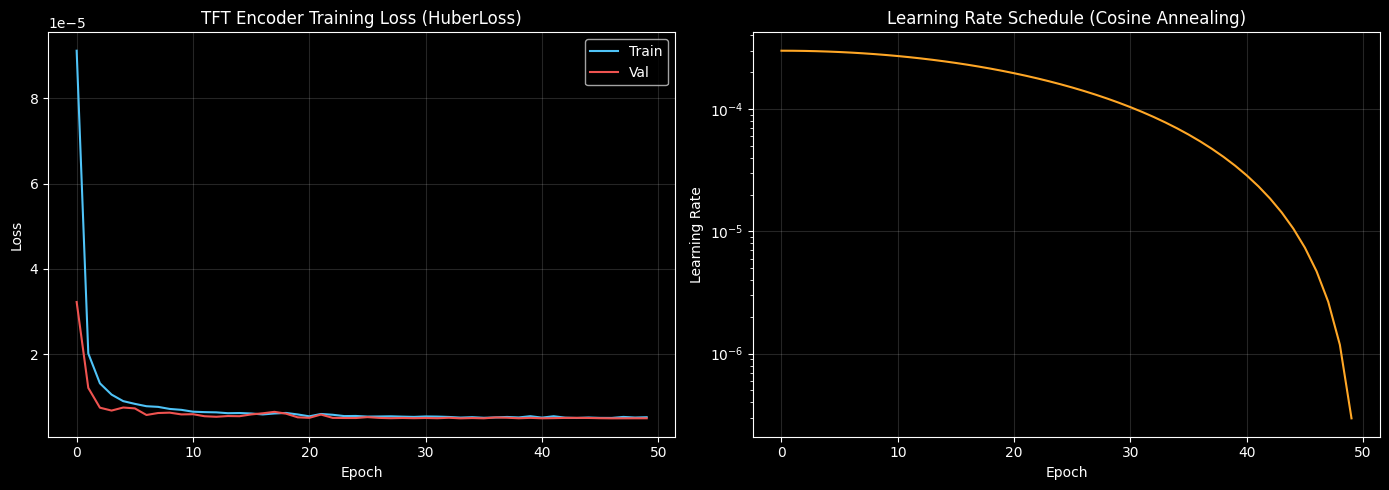

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    history["train_loss"],
    color=COLORS["primary"],
    label="Train",
    linewidth=1.5,
)
axes[0].plot(
    history["val_loss"], color=COLORS["danger"], label="Val", linewidth=1.5
)
axes[0].set_title("TFT Encoder Training Loss (HuberLoss)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.15)

axes[1].plot(history["lr"], color=COLORS["warning"], linewidth=1.5)
axes[1].set_title("Learning Rate Schedule (Cosine Annealing)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning Rate")
axes[1].set_yscale("log")
axes[1].grid(alpha=0.15)

plt.tight_layout()
plt.savefig("06/06_tft_training.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Embedding Quality Analysis

In [8]:
# Load best checkpoint and generate embeddings for the validation set
model_tft.load_state_dict(
    torch.load("06/06_tft_encoder_best.pt", map_location=DEVICE)
)
model_tft.eval()

all_embeddings = []
all_targets = []

with torch.no_grad():
    for xb, yb, sb in loader_va:
        xb, yb, sb = xb.to(DEVICE), yb.to(DEVICE), sb.to(DEVICE)
        emb, _, _ = model_tft(xb, sb)
        all_embeddings.append(emb.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

embeddings = np.vstack(all_embeddings)  # (n_val, 128)
val_rets = np.concatenate(all_targets)

print(f"Embedding matrix shape: {embeddings.shape}")
print(f"  Mean   : {embeddings.mean():.4f}")
print(f"  Std    : {embeddings.std():.4f}")
print(f"  Min    : {embeddings.min():.4f}")
print(f"  Max    : {embeddings.max():.4f}")

# Embedding dimension utilisation (dead neurons analysis)
dead_dims = (embeddings.std(axis=0) < 0.01).sum()
print(
    f"  Dead embedding dims (std < 0.01): {dead_dims} / {EMBEDDING_DIM_TEMPORAL}"
)

Embedding matrix shape: (681, 128)
  Mean   : 0.0003
  Std    : 0.4902
  Min    : -0.9570
  Max    : 0.9517
  Dead embedding dims (std < 0.01): 0 / 128


Running t-SNE on TFT embeddings (may take ~30s)...


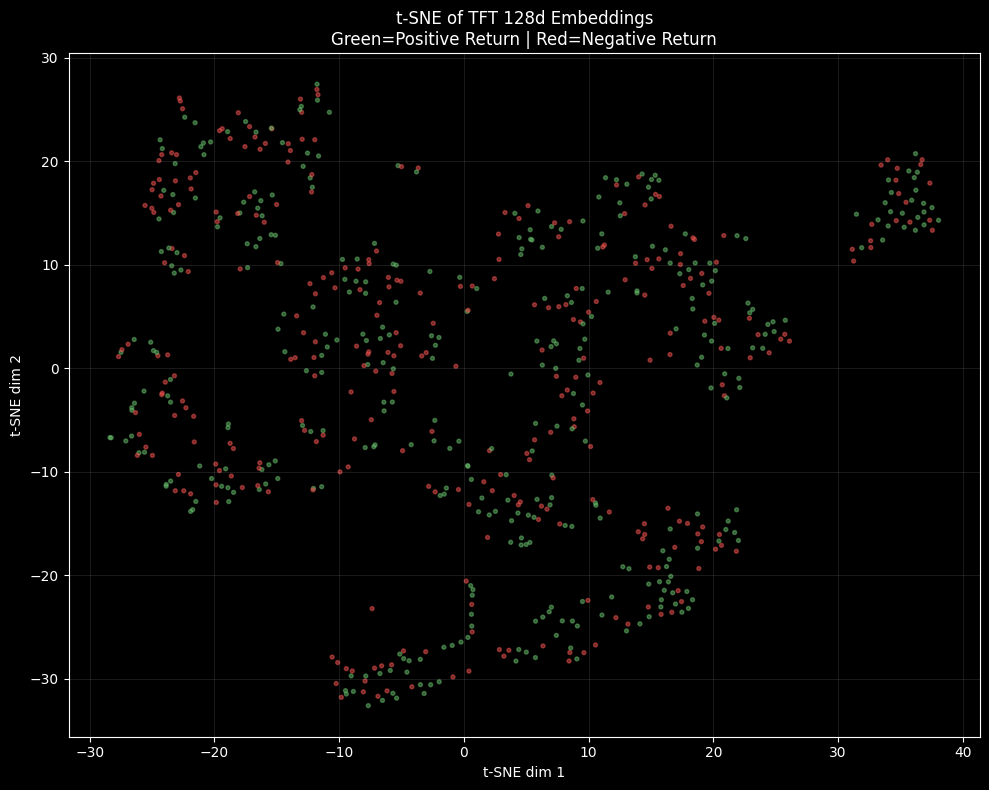

t-SNE complete — check for regime cluster separation ✅


In [9]:
# t-SNE visualisation of 128d embeddings coloured by return sign
# This is the Q2 Milestone: "We should see Crash states clustering together."
try:
    from sklearn.manifold import TSNE

    print("Running t-SNE on TFT embeddings (may take ~30s)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
    emb_2d = tsne.fit_transform(embeddings[:2000])  # Sample 2000 for speed

    return_labels = (val_rets[:2000] > 0).astype(int)
    colors_tsne = [
        COLORS["success"] if l == 1 else COLORS["danger"]
        for l in return_labels
    ]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors_tsne, alpha=0.5, s=8)
    ax.set_title(
        "t-SNE of TFT 128d Embeddings\n"
        "Green=Positive Return | Red=Negative Return"
    )
    ax.set_xlabel("t-SNE dim 1")
    ax.set_ylabel("t-SNE dim 2")
    ax.grid(alpha=0.10)
    plt.tight_layout()
    plt.savefig("06/06_tft_tsne.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("t-SNE complete — check for regime cluster separation ✅")

except ImportError:
    print("scikit-learn not found — skipping t-SNE.  pip install scikit-learn")

## 8. VSN Weight Interpretability

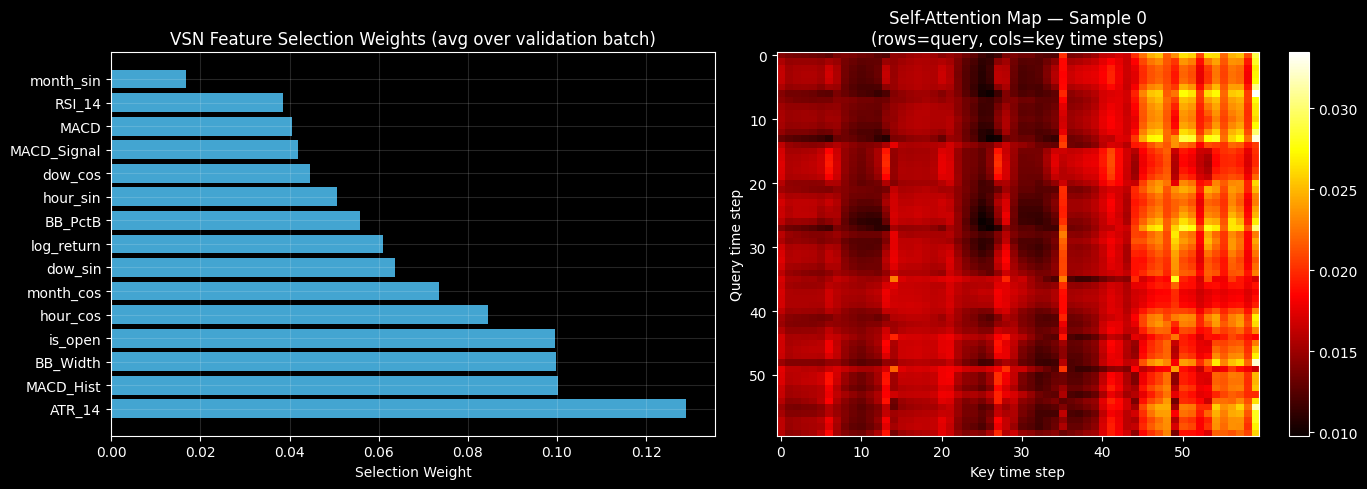

In [10]:
# Visualise which features the VSN selects on a sample of validation windows.
model_tft.eval()
sample_x = torch.tensor(X_va[:32]).to(DEVICE)
sample_s = torch.tensor(s_va[:32]).to(DEVICE)

with torch.no_grad():
    _, vsn_weights, attn_weights = model_tft(sample_x, sample_s)

# Average VSN weights across batch and time — shows overall feature importance
mean_vsn = vsn_weights.mean(dim=(0, 1)).cpu().numpy()  # (n_features,)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance bar chart
sorted_idx = np.argsort(mean_vsn)[::-1]
axes[0].barh(
    [feature_cols[i] for i in sorted_idx],
    mean_vsn[sorted_idx],
    color=COLORS["primary"],
    alpha=0.85,
)
axes[0].set_title("VSN Feature Selection Weights (avg over validation batch)")
axes[0].set_xlabel("Selection Weight")
axes[0].grid(alpha=0.15)

# Attention heatmap for first sample (temporal pattern)
attn_sample = attn_weights[0].cpu().numpy()  # (seq_len, seq_len)
im = axes[1].imshow(attn_sample, cmap="hot", aspect="auto")
axes[1].set_title(
    "Self-Attention Map — Sample 0\n(rows=query, cols=key time steps)"
)
axes[1].set_xlabel("Key time step")
axes[1].set_ylabel("Query time step")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.savefig("06/06_tft_interpretability.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Export — Embedding Vectors to Redis-Compatible Format

In [11]:
# Produce the embedding dictionary format that backend/perception/temporal/inference.py
# will push to Redis using the key pattern: embeddings:price:{TICKER}
def generate_embedding_payload(
    ticker: str, embedding: np.ndarray, timestamp: pd.Timestamp
) -> dict:
    """
    Serialise the TFT embedding to the Redis payload format.
    Key: embeddings:price:{ticker}
    TTL: REDIS_TTL_PRICE = 120 seconds
    """
    return {
        "ticker": ticker,
        "timestamp": timestamp.isoformat(),
        "dim": EMBEDDING_DIM_TEMPORAL,
        "vector": embedding.tolist(),  # JSON-serialisable for Redis
        "source": "tft_encoder_v3",
        "ttl_seconds": 120,  # REDIS_TTL_PRICE from constants.py
    }


# Show a sample payload
sample_embedding = embeddings[0]
payload = generate_embedding_payload(
    "SPY", sample_embedding, pd.Timestamp.now()
)
print("Sample Redis payload:")
print(f"  key     : embeddings:price:{payload['ticker']}")
print(f"  dim     : {payload['dim']}")
print(f"  ttl     : {payload['ttl_seconds']}s")
print(
    f"  vector  : [{payload['vector'][0]:.4f}, {payload['vector'][1]:.4f}, ...]"
)

# Save embedding checkpoint for notebook 08 (Fusion Layer)
np.save("06/06_val_embeddings_temporal.npy", embeddings)
print("\nSaved validation embeddings → 06_val_embeddings_temporal.npy")
print(f"Shape: {embeddings.shape}  (n_samples, EMBEDDING_DIM_TEMPORAL=128)")
print(
    "These will be concatenated with semantic (64d) and structural (32d) in notebook 08."
)

Sample Redis payload:
  key     : embeddings:price:SPY
  dim     : 128
  ttl     : 120s
  vector  : [0.4712, 0.6147, ...]

Saved validation embeddings → 06_val_embeddings_temporal.npy
Shape: (681, 128)  (n_samples, EMBEDDING_DIM_TEMPORAL=128)
These will be concatenated with semantic (64d) and structural (32d) in notebook 08.
